# Cyber Trend Forecasting - VisionTS Pipeline

**Vignette Description:**
This notebook acts as the Pipeline Dashboard for the VisionTS model. It handles the end-to-end workflow:
1.  **Setup:** Automatically detects if running on Google Colab or the NATO Local Server.
2.  **Training:** Executes `Train_Vision.py` to train/evaluate the VisionTS model.
3.  **Evaluation:** Runs `Evaluate_Vision.py` to generate metrics and predictions.
4.  **Visualisation:** Runs `Visualise_VisionPP_Results.py` and displays the Gap Analysis inline.

**Model Architecture:**
VisionTS converts time series to 2D image representations and leverages a pretrained Masked Autoencoder (MAE) for forecasting.

## Universal Setup

This cell handles the setup logic: mounting Google Drive if on Colab, or using relative paths if on the GPU server

In [1]:
import os
import sys

# --- CONFIGURATION ---
# If on Colab, ensure you have set the Secret 'project_path' to your Project Root
# e.g., /content/drive/MyDrive/NATO_Project_Root

try:
    # 1. CHECK ENVIRONMENT: Try to import Colab-specific modules
    from google.colab import drive, userdata
    IS_COLAB = True
    print("--- Detected Environment: GOOGLE COLAB ---")
except ImportError:
    IS_COLAB = False
    print("--- Detected Environment: LOCAL SERVER (NATO/BBK) ---")

# 2. PATH SETUP
if IS_COLAB:
    # --- COLAB SETUP ---
    try:
        drive.mount('/content/drive')

        # Get the PARENT ROOT from Secrets
        PROJECT_ROOT = userdata.get('project_path')
        if not PROJECT_ROOT:
            raise ValueError("Secret 'project_path' is missing.")

    except Exception as e:
        print(f"COLAB SETUP ERROR: {e}")
        # Stop execution if we can't find the files
        raise e
else:
    # --- LOCAL SETUP ---
    # We assume this notebook is in 'Notebooks/', so Root is one level up
    # os.getcwd() returns /.../Project_Root/Notebooks
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 3. CONFIGURE WORKING DIRECTORY
# We need to run scripts from inside 'Transformer_Pipeline'
PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'Transformer_Pipeline')

if not os.path.exists(PIPELINE_DIR):
    raise FileNotFoundError(f"Could not find pipeline folder at: {PIPELINE_DIR}")

# Change CWD to the pipeline folder so scripts can find config/data
os.chdir(PIPELINE_DIR)
print(f"SUCCESS: Working Directory set to: {os.getcwd()}")

# 4. ADD PROJECT ROOT TO SYS.PATH
# This allows us to import 'Notebooks.colab_utils' if needed
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added Project Root to sys.path: {PROJECT_ROOT}")

# 5. INSTALL DEPENDENCIES (COLAB ONLY)
if IS_COLAB:
    print("\n--- Installing Dependencies (Colab Only) ---")
    # We import the helper script from the sibling folder
    try:
        from Notebooks import colab_utils
        colab_utils.setup_environment()
    except ImportError:
        print("WARNING: Could not import Notebooks.colab_utils. Skipping auto-install.")

--- Detected Environment: GOOGLE COLAB ---
Mounted at /content/drive
SUCCESS: Working Directory set to: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline
Added Project Root to sys.path: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting

--- Installing Dependencies (Colab Only) ---


### Imports

In [2]:
from pathlib import Path

from Transformer_Pipeline.Visualise_VisionPP_Results import (
    visualise_evaluation_metrics,
    load_visualisation_data,
    perform_broad_analysis,
    plot_validation_forecasts,
    generate_gap_analysis_tables,
    plot_continuous_trends
)

## Optional: Re-Generate Vision Data

Run this cell if you want to rebuild the vision artifacts from the raw CSV data. If you have already processed the data, you can skip this step.

In [ ]:
# 1. Your manual print statements will show up perfectly
print("--- Generating VisionTS++ Data ---")
print("--- Step 1: Generating Base Data (Bypassing Wrapper Bug) ---")

# 2. Add 2>/dev/null to the end of the command to swallow the warnings
!{sys.executable} -W ignore -m Preprocessing.Cyber_Trend_to_Image \
    --window-first \
    --feature-selection \
    --n-features 25 \
    --force-vignette-features 2>/dev/null

print("\n--- Step 2: Setting up VisionPP Folder ---")
!{sys.executable} -W ignore -m Preprocessing.Cyber_Trend_to_Image_PP --force 2>/dev/null

## Step 1: Train VisionTS Model

We now execute the training script.
* **Input:** `Cyber_Trend_Vision_Config.py` (Hyperparameters)
* **Output:** `vision_best.pt` (Saved weights)

The model will be fine-tuned on the cyber threat data to learn domain-specific patterns.

*Note: Training on T4 GPU should take ~5-10 minutes.*

In [ ]:
print("--- Step 1: Training VisionTS Model ---")
# We use %run to execute the script in a fresh namespace.
# This runs the script as if it were in the terminal, showing live progress bars.
# This is cleaner for demo purposes than importing the main function.
# Adding --num_runs 10 and --batch_size 4 to trigger the Best-of-10 training loop.
%run Train_VisionPP.py --data_dir ../Processed_Data/visionpp --mode train --epochs 50 --num_runs 10 --batch_size 4

## Step 2: Evaluation & Metrics

This step loads the best model saved above and runs it against the Test Set.
* It calculates **RSE, RAE, MAE, and CORR** across horizons (3, 6, 12, 24 months).
* It saves the raw predictions to `.npy` files for visualisation.
* It exports the results to a CSV file.

--- Step 2: Evaluating Model on Test Set ---
--- Loading Test Data from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/visionpp ---
Initializing VisionTS dataset for split: test from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/visionpp
Loading windowed data from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/visionpp/test.npz...
Loaded 25 samples for test.
  X shape: (25, 36, 25) (samples, context_len, nvars)
  y shape: (25, 36, 25) (samples, pred_len, nvars)
Test samples: 25
Dimensions: context=36, pred=36, features=25

--- Loading VisionTS++ Model ---
Init VisionTS++ wrapper:
  - Architecture: mae_base
  - Fine-tune type: ln
  - Context length: 36
  - Prediction length: 36
  - Number of features: 25
  - Quantile prediction: True
  - Color encoding: True
Load /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/visionpp/ckpt/visiontspp_model.ckpt
  - Per

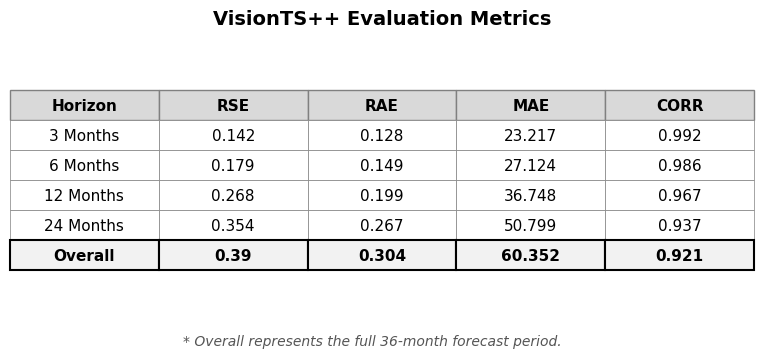

In [3]:
print("--- Step 2: Evaluating Model on Test Set ---")
# Execute the evaluation script natively
%run Evaluate_VisionPP.py --data_dir ../Processed_Data/visionpp

print("\n--- PUBLICATION PREVIEW: Evaluation Metrics ---")
# Natively draw the table
visualise_evaluation_metrics()

## Step 3: Visualisation

Finally, we generate the paper-ready plots.
* **Forecast vs Actual:** Checks model accuracy on a specific node.
* **Gap Analysis:** Visualises the "Risk Gap" between **DDoS-ALL** (Threat) and **IDS/IPS Solutions** (Mitigation).

In [3]:
current_dir = Path.cwd()
if str(current_dir.parent) not in sys.path: sys.path.append(str(current_dir.parent))

# Load data into vis_data
vis_data = load_visualisation_data()

if vis_data:
    print("Data Loaded Successfully.")
else:
    print("Failed to load data.")

--- Loading VisionPP Visualisation Data ---
Raw predictions shape: (25, 36, 25)
Raw ground truth shape: (25, 36, 25)
Feature names loaded: 25 features
Averaged predictions shape: (36, 25)
Loading Full History from: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Data_Preparation/Cyber_Trend_Forecasting_All.csv
Data Loaded Successfully.


### Broad Analysis: Global Trends
This cell generates two high-level aggregate plots to assess the overall state of the cybersecurity landscape:

* **Global Forecast Accuracy:** Compares the **Global Average Ground Truth** (Black) against the **Global Average Prediction** (Blue) across all nodes. This provides a macroscopic view of the model's reliability.
* **Global Gap Analysis (Threat Intensity vs Mitigation Maturity):** Plots the **Average Threat Intensity** (Red) against the **Average Mitigation Maturity** (Green) for the entire dataset.
    * **Risk Gap (Red Shading):** Indicates periods where threats generally outpace available solutions.
    * **Safety Margin (Green Shading):** Indicates periods where defense maturity exceeds threat intensity.


--- FORECAST ACCURACY: Ground Truth vs Prediction ---
Saved: Global_Forecast_Accuracy.png (and archived to archive/)


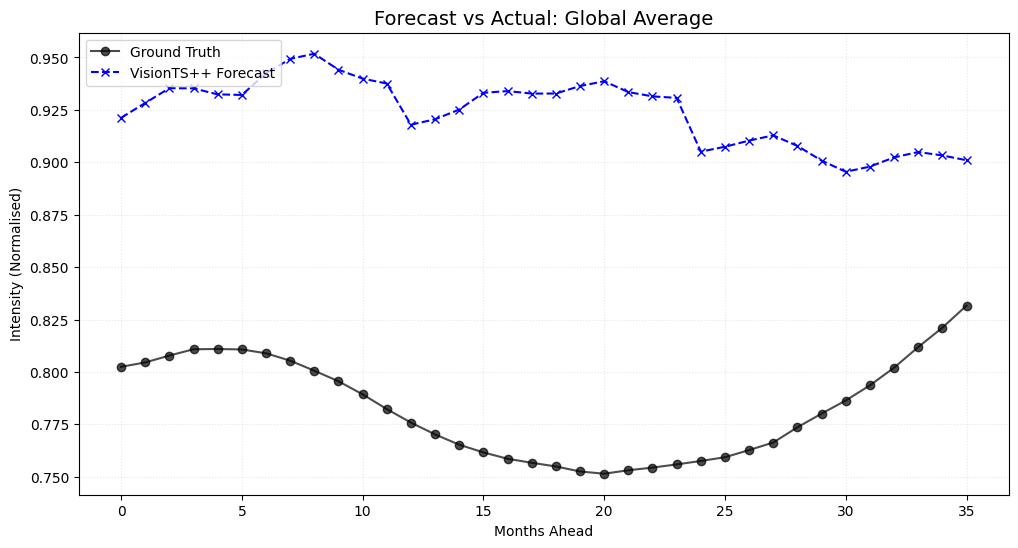


--- GAP ANALYSIS: Threat vs Mitigation ---
Saved: Global_Gap_Analysis.png (and archived to archive/)


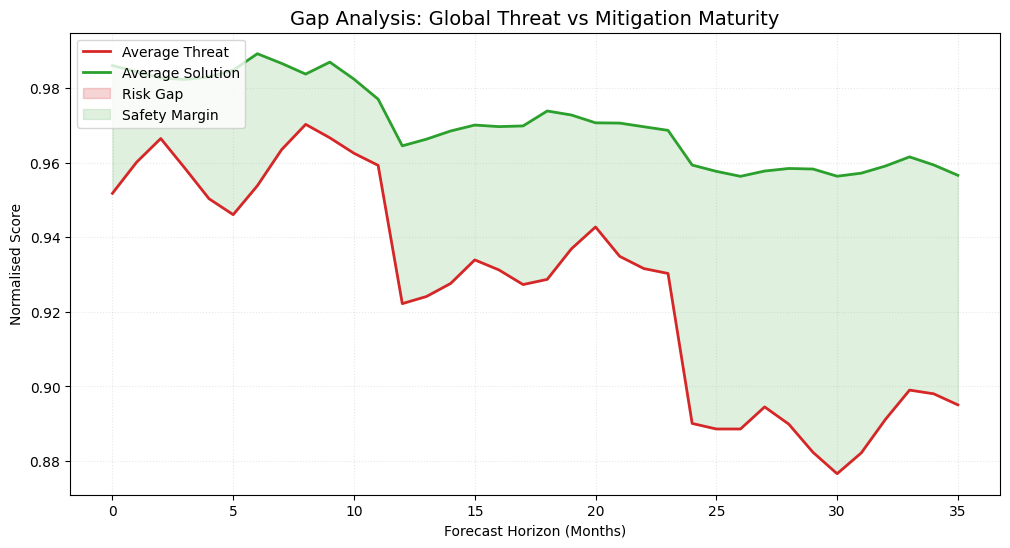

In [4]:
if vis_data:
    perform_broad_analysis(vis_data)

### Forecast Accuracy (Ground Truth vs Prediction)
This cell generates the validation plots corresponding to **Figure 3** in the paper. It visualises the model's performance on specific, high-priority validation nodes (e.g., *Password Attack*, *NLP/LLM*, *Data Backups*).

* **Visuals:** It plots the **Actual Ground Truth** (Black Line) versus the **PDFormer Forecast** (Red Dashed Line) over the test period.
* **Confidence:** The shaded region represents the **95% Confidence Interval** of the prediction.
* **Grid View:** In addition to the detailed individual plots, it generates a grid view of all validation nodes to allow for a comprehensive performance assessment at a glance.


--- Figure 3: Forecast Accuracy (Ground Truth vs Prediction) ---


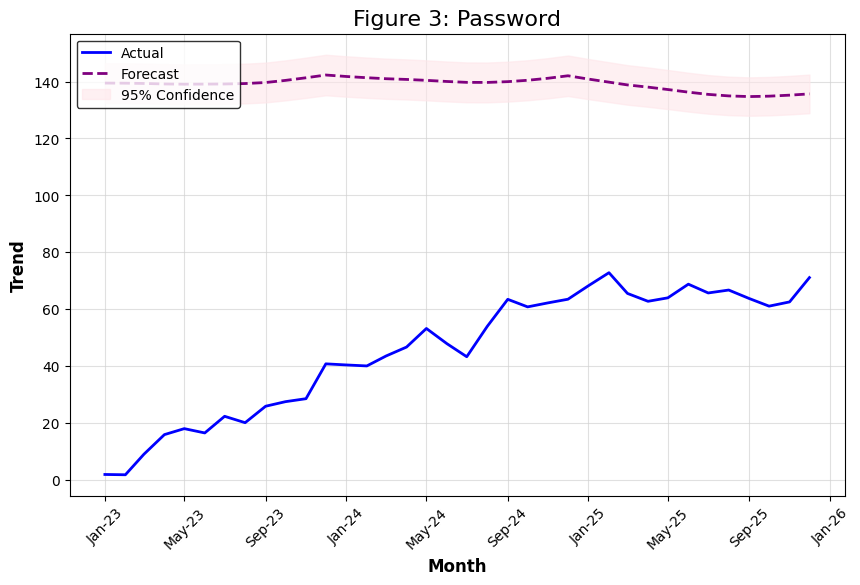

Saved: Fig3_Password.png (and archived to archive/)


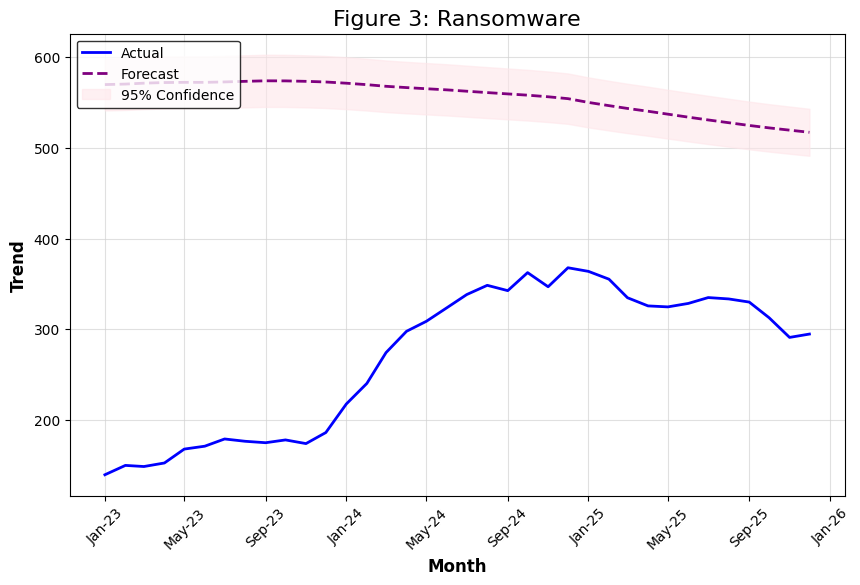

Saved: Fig3_Ransomware.png (and archived to archive/)


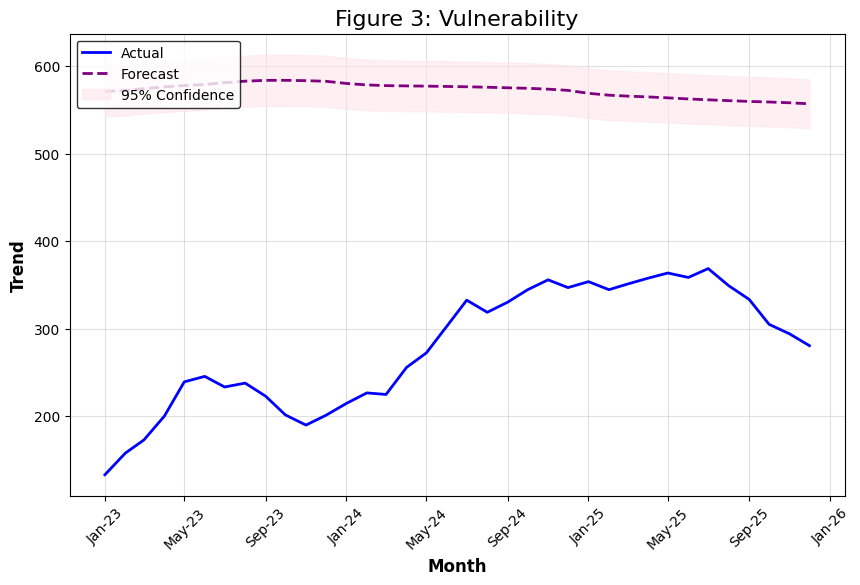

Saved: Fig3_Vulnerability.png (and archived to archive/)


In [4]:
if vis_data:
    plot_validation_forecasts(vis_data)

### Gap Analysis Tables (Tables 5 & 6)
This cell performs a quantitative analysis of the "Risk Gap" defined in the paper. It calculates the numerical difference between Threat Intensity and Solution Maturity for every pair in the knowledge graph over the forecast window (2023–2025).

* **Table 5 (Widening Gaps):** Identifies pairs where the gap is increasing year-over-year (Strictly Widening) or is larger at the end of the period than the start (Overall Widening). These represent emerging risks.
* **Table 6 (Narrowing Gaps):** Identifies pairs where the gap is decreasing, indicating "Success Stories" where mitigation strategies are effectively catching up to the threat.


--- PUBLICATION PREVIEW: Top Widening Risks ---

--- GAP TABLES: Widening & Narrowing ---
Saved: Overall_Widening.png (and archived to archive/)


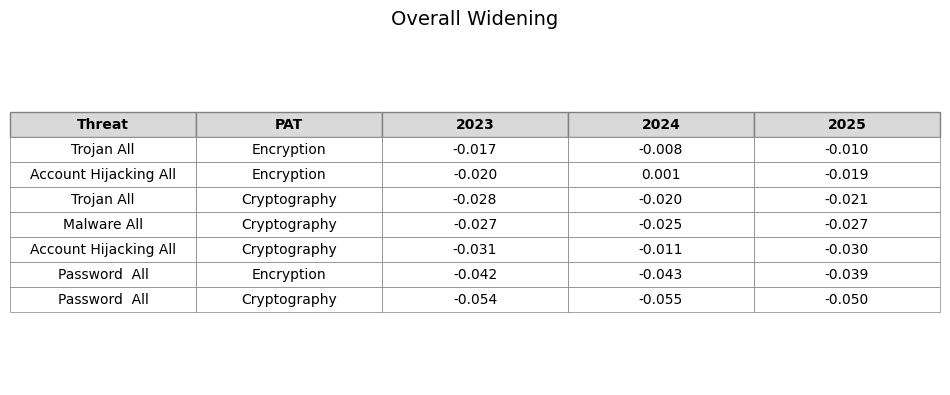


--- Table 5b: Overall Widening Gaps (Top 5) ---
               Threat          PAT   2023   2024   2025
           Trojan All   Encryption -0.017 -0.008 -0.010
Account Hijacking All   Encryption -0.020  0.001 -0.019
           Trojan All Cryptography -0.028 -0.020 -0.021
          Malware All Cryptography -0.027 -0.025 -0.027
Account Hijacking All Cryptography -0.031 -0.011 -0.030
Saved: Strictly_Narrowing.png (and archived to archive/)


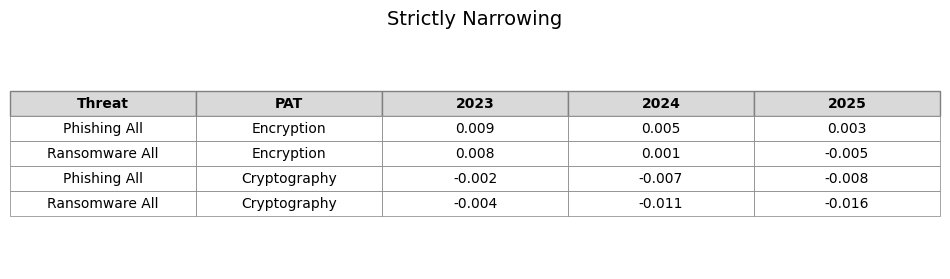


--- Table 6a: Strictly Narrowing Gaps (Top 5) ---
        Threat          PAT   2023   2024   2025
  Phishing All   Encryption  0.009  0.005  0.003
Ransomware All   Encryption  0.008  0.001 -0.005
  Phishing All Cryptography -0.002 -0.007 -0.008
Ransomware All Cryptography -0.004 -0.011 -0.016
Saved: Overall_Narrowing.png (and archived to archive/)


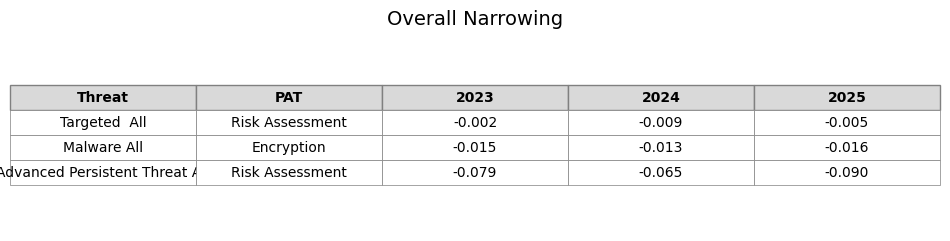


--- Table 6b: Overall Narrowing Gaps (Top 5) ---
                        Threat             PAT   2023   2024   2025
                 Targeted  All Risk Assessment -0.002 -0.009 -0.005
                   Malware All      Encryption -0.015 -0.013 -0.016
Advanced Persistent Threat All Risk Assessment -0.079 -0.065 -0.090


In [5]:
if vis_data:
    print("\n--- PUBLICATION PREVIEW: Top Widening Risks ---")
    generate_gap_analysis_tables(vis_data)

### Continuous Trends (2011–2028)
This cell generates **Figure 4**, which stitches the historical data (2011–2022) with the model's forecast (2023–2028) to visualise the continuous 14-year evolution of major threat vectors (e.g., *Malware*, *Ransomware*).

* **The Trend:** The Black Line represents the continuous trend from the past into the future.
* **The Forecast:** The future period (2023–2025) includes 95% confidence shading.
* **Mitigation Context:** Where applicable, relevant solution trends (Green/Blue lines) are plotted alongside the threat to visualise the long-term interaction between attack vectors and defense mechanisms.


--- PAPER FIG 4: Continuous Trends ---
Saved: Fig4_Malware.png (and archived to archive/)


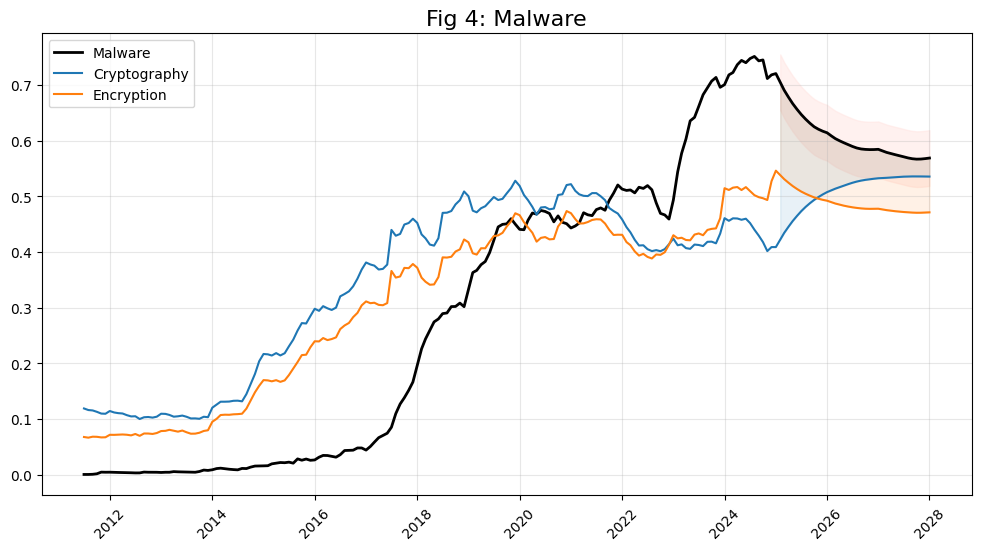

Saved: Fig4_Vulnerability.png (and archived to archive/)


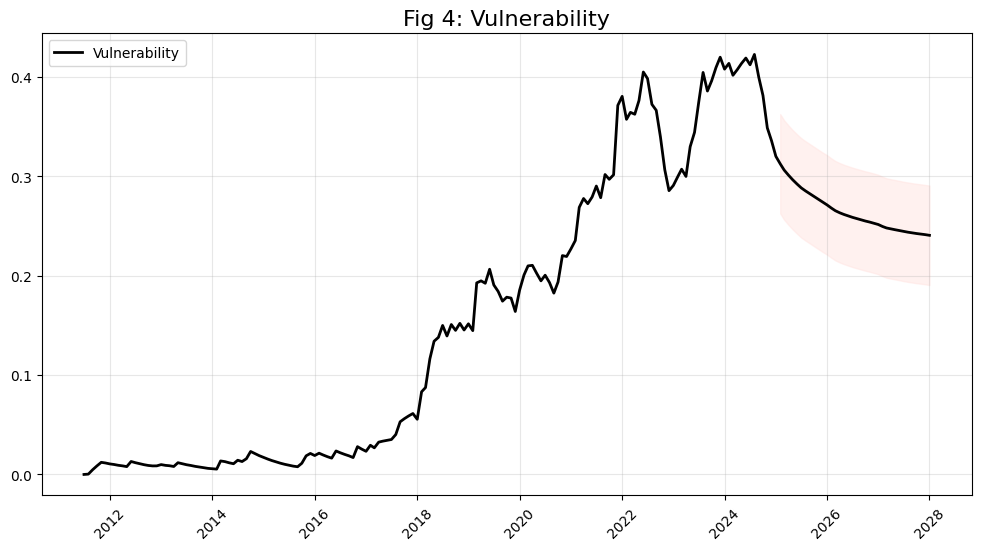

Saved: Fig4_Ransomware.png (and archived to archive/)


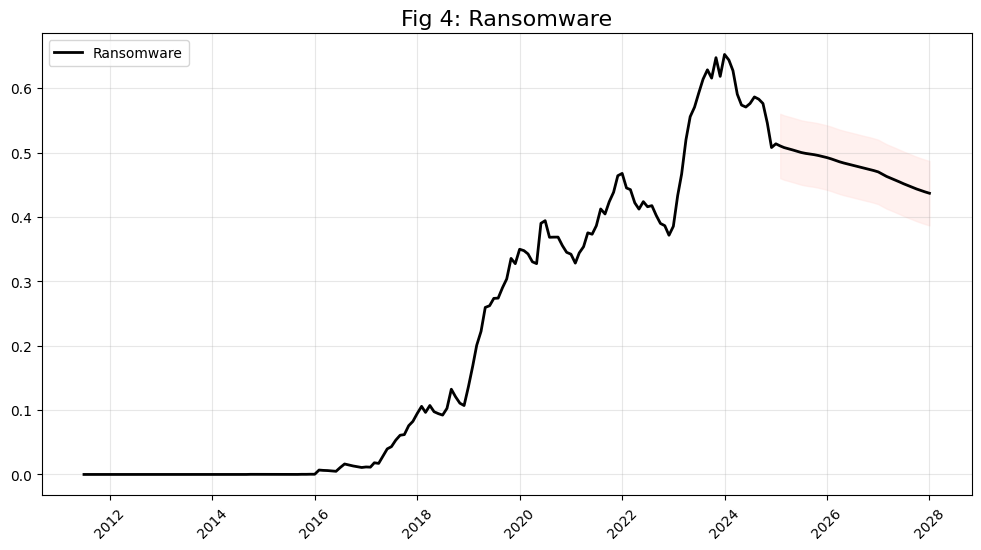

In [8]:
if vis_data:
    plot_continuous_trends(vis_data)

### Execute Full Pipeline
This cell executes the entire `Visualise_VisionPP_Results.py` script in one go using the `%run` command.

Using `%run` here ensures that the visualisation functions and loaded data remain accessible in the notebook session for further inspection if needed.


--- Loading VisionPP Visualisation Data ---
Raw predictions shape: (25, 36, 25)
Raw ground truth shape: (25, 36, 25)
Feature names loaded: 25 features
Averaged predictions shape: (36, 25)
Loading Full History from: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Data_Preparation/Cyber_Trend_Forecasting_All.csv

--- FORECAST ACCURACY: Ground Truth vs Prediction ---


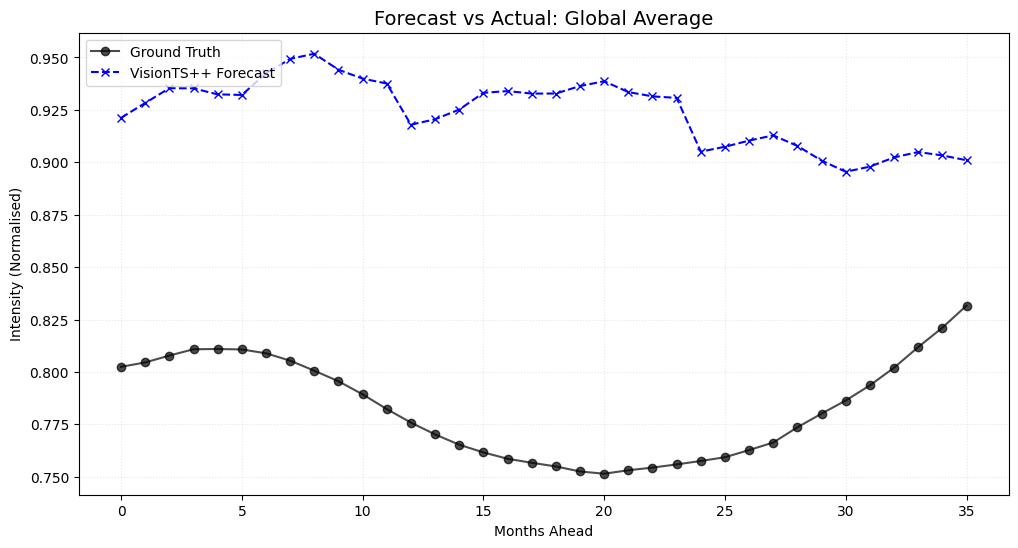

Saved: Global_Forecast_Accuracy.png (and archived to archive/)

--- GAP ANALYSIS: Threat vs Mitigation ---


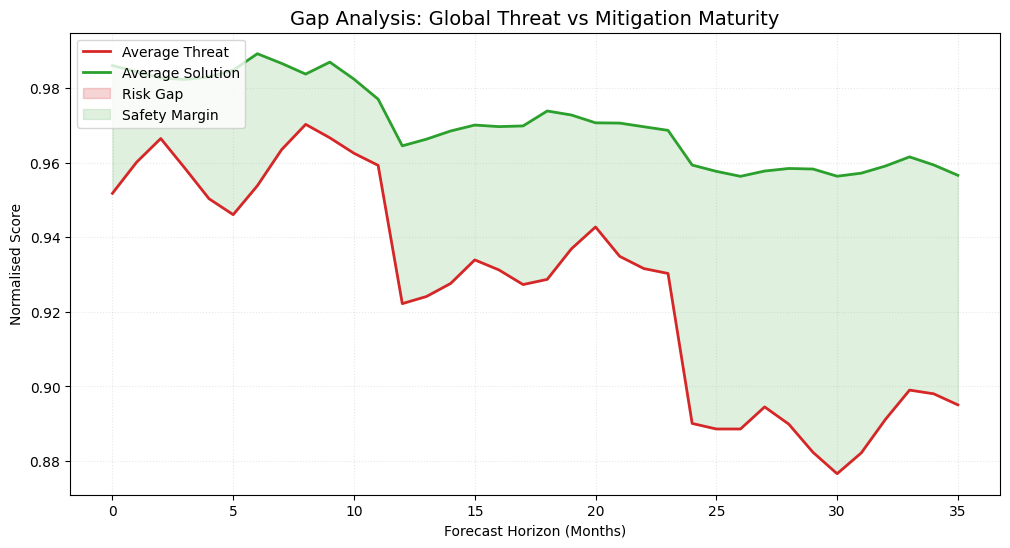

Saved: Global_Gap_Analysis.png (and archived to archive/)

--- Figure 3: Forecast Accuracy (Ground Truth vs Prediction) ---


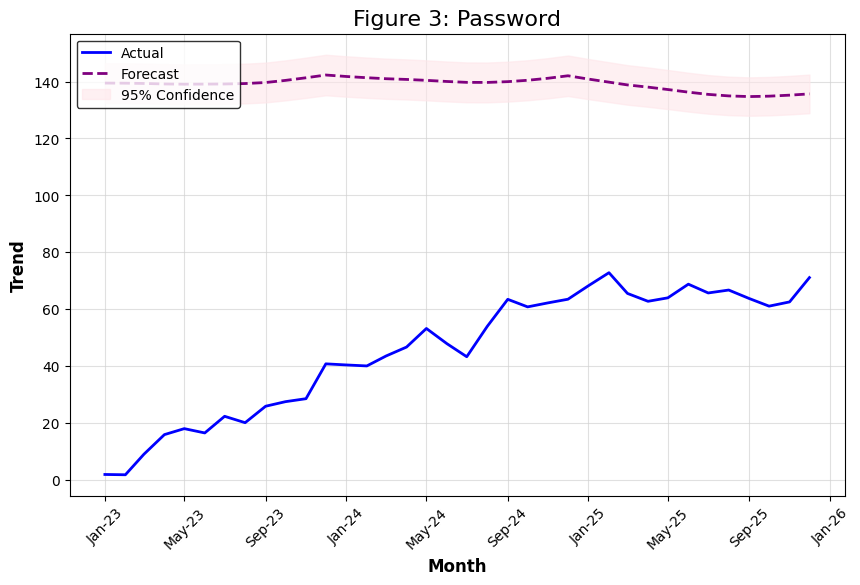

Saved: Fig3_Password.png (and archived to archive/)


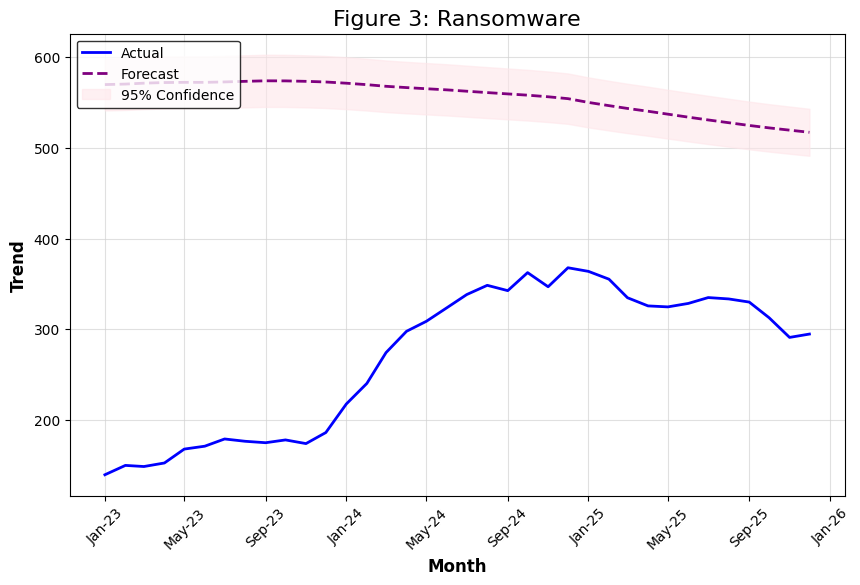

Saved: Fig3_Ransomware.png (and archived to archive/)


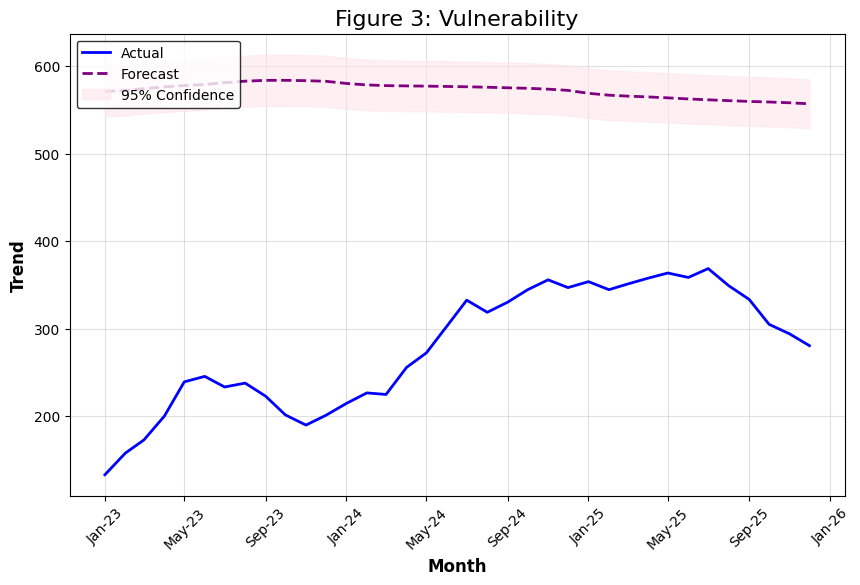

Saved: Fig3_Vulnerability.png (and archived to archive/)

--- GAP TABLES: Widening & Narrowing ---


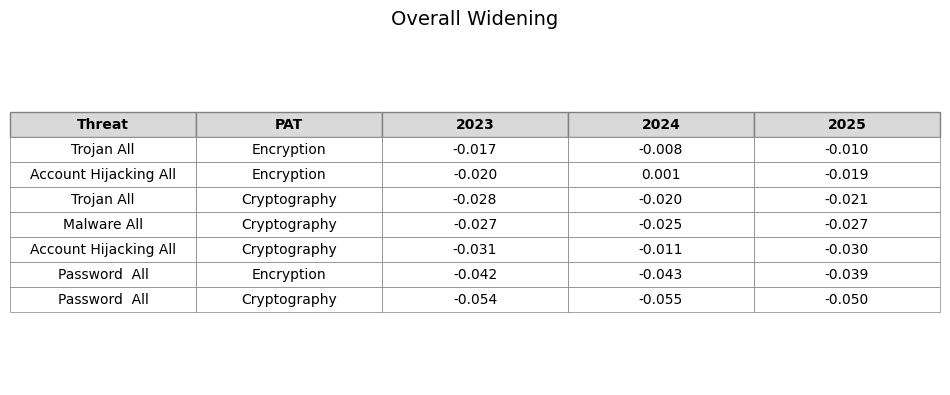

Saved: Overall_Widening.png (and archived to archive/)

--- Table 5b: Overall Widening Gaps (Top 5) ---
               Threat          PAT   2023   2024   2025
           Trojan All   Encryption -0.017 -0.008 -0.010
Account Hijacking All   Encryption -0.020  0.001 -0.019
           Trojan All Cryptography -0.028 -0.020 -0.021
          Malware All Cryptography -0.027 -0.025 -0.027
Account Hijacking All Cryptography -0.031 -0.011 -0.030


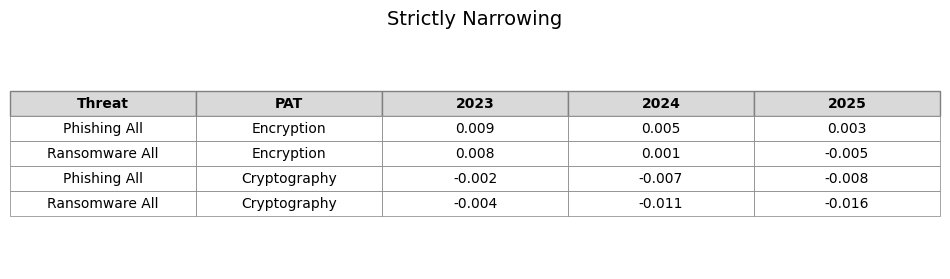

Saved: Strictly_Narrowing.png (and archived to archive/)

--- Table 6a: Strictly Narrowing Gaps (Top 5) ---
        Threat          PAT   2023   2024   2025
  Phishing All   Encryption  0.009  0.005  0.003
Ransomware All   Encryption  0.008  0.001 -0.005
  Phishing All Cryptography -0.002 -0.007 -0.008
Ransomware All Cryptography -0.004 -0.011 -0.016


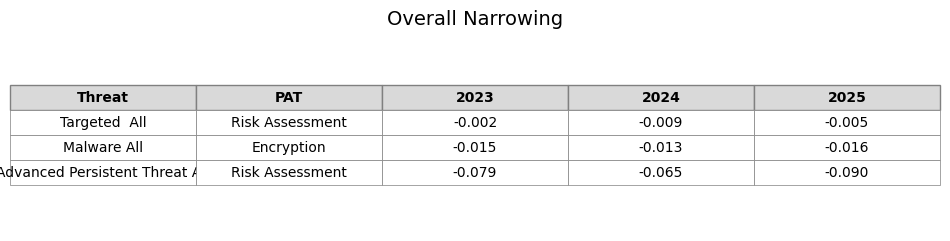

Saved: Overall_Narrowing.png (and archived to archive/)

--- Table 6b: Overall Narrowing Gaps (Top 5) ---
                        Threat             PAT   2023   2024   2025
                 Targeted  All Risk Assessment -0.002 -0.009 -0.005
                   Malware All      Encryption -0.015 -0.013 -0.016
Advanced Persistent Threat All Risk Assessment -0.079 -0.065 -0.090

--- PAPER FIG 4: Continuous Trends ---


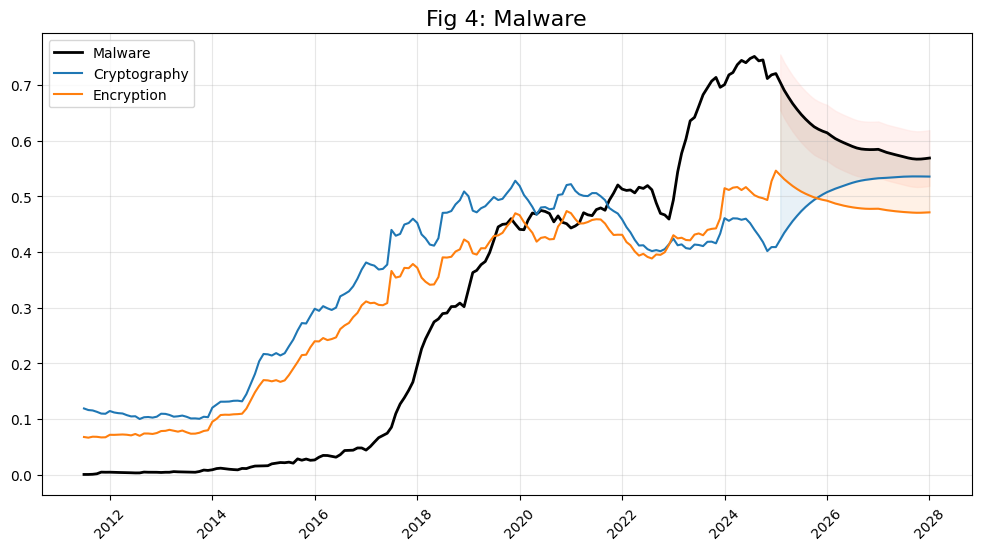

Saved: Fig4_Malware.png (and archived to archive/)


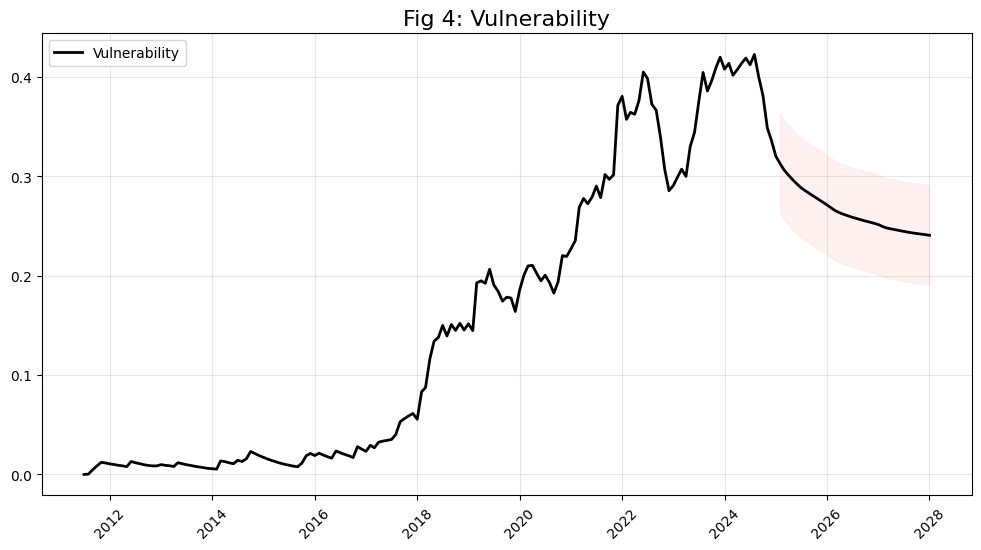

Saved: Fig4_Vulnerability.png (and archived to archive/)


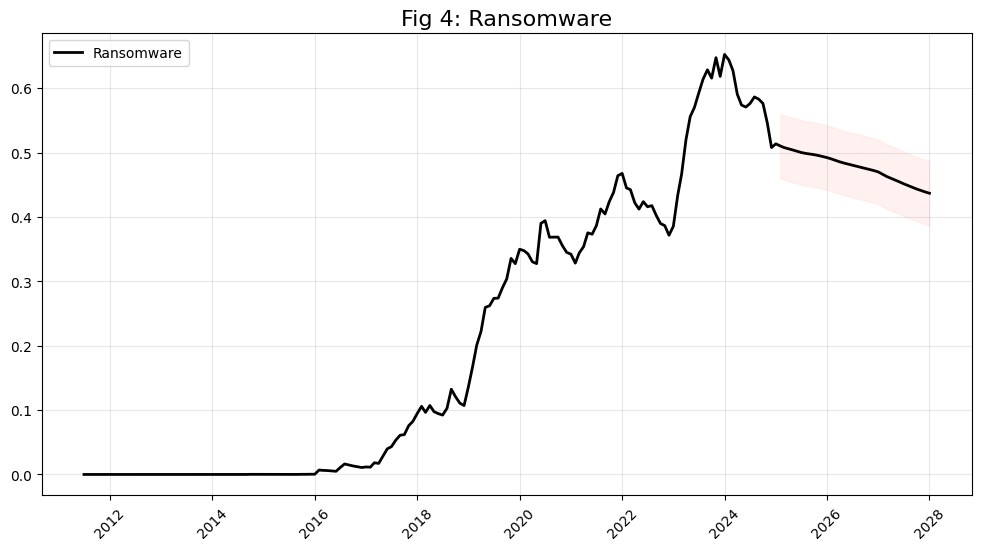

Saved: Fig4_Ransomware.png (and archived to archive/)


<Figure size 640x480 with 0 Axes>

In [5]:
%run Visualise_VisionPP_Results.py